In [149]:
import torch
from benchmark_utils import timeit
import tqdm
import pandas as pd
import matplotlib.pyplot as plt

In [150]:
def benchmark(
    n: int,
    k: int,
    dtype: type,
    warmup_iters: int = 5,
    iters: int = 10,
    repetitions: int = 3,
):
    assert n % k == 0

    x = torch.rand(size=(n,), dtype=dtype, device="cuda")

    y_sr = None

    solvers_per_coarse = torch.full(
        size=(n // k,), fill_value=k, dtype=torch.int32, device="cuda"
    )
    solvers_per_coarse_scan = torch.empty(
        n // k + 1,
        device="cuda",
        dtype=torch.int32,
    )
    solvers_per_coarse_scan[0] = 0
    solvers_per_coarse_scan[1:] = solvers_per_coarse.cumsum(dim=0)

    def segment_reduce(x):
        nonlocal y_sr

        y_sr = torch.segment_reduce(x, reduce="sum", offsets=solvers_per_coarse_scan)
        return y_sr

    y_ia_ = None

    solvers_to_coarse = torch.arange(n // k, device="cuda").repeat_interleave(k)

    def index_add_(x):
        nonlocal y_ia_
        res = torch.zeros(size=(n // k,), dtype=dtype, device="cuda")
        res.index_add_(0, solvers_to_coarse, x)
        y_ia_ = res
        return res

    results = {}
    for f in [segment_reduce, index_add_]:
        results[f.__name__] = timeit(
            lambda: f(x),
            warmup_iters=warmup_iters,
            iters=iters,
            repetitions=repetitions,
        )

    assert torch.allclose(y_sr, y_ia_)

    return results

In [151]:
Ns = [2**12, 2**20, 2**24]
ks = range(1, 128)
dtypes = [torch.float32, torch.float64]

In [152]:
tests = [(N, k, dtype) for N in Ns for k in ks for dtype in dtypes]
len(tests)

762

In [153]:
results = []
for N, k, dtype in tqdm.tqdm(tests):
    n = N // k * k
    results.append({"N": N, "k": k, "dtype": dtype, **benchmark(n=n, k=k, dtype=dtype)})

100%|██████████| 762/762 [00:22<00:00, 33.69it/s] 


In [154]:
df = pd.DataFrame(results)
df

,N,k,dtype,segment_reduce,index_add_
0,4096,1,torch.float32,0.021030,0.018528
1,4096,1,torch.float64,0.020998,0.018218
2,4096,2,torch.float32,0.020781,0.018086
3,4096,2,torch.float64,0.023744,0.021299
4,4096,3,torch.float32,0.023974,0.020112
...,...,...,...,...,...
757,16777216,125,torch.float64,0.270016,0.586470
758,16777216,126,torch.float32,0.242086,0.643226
759,16777216,126,torch.float64,0.268550,0.587114
760,16777216,127,torch.float32,0.241136,0.659891


In [155]:
funs = df.columns[3:]
funs

Index(['segment_reduce', 'index_add_'], dtype='object')

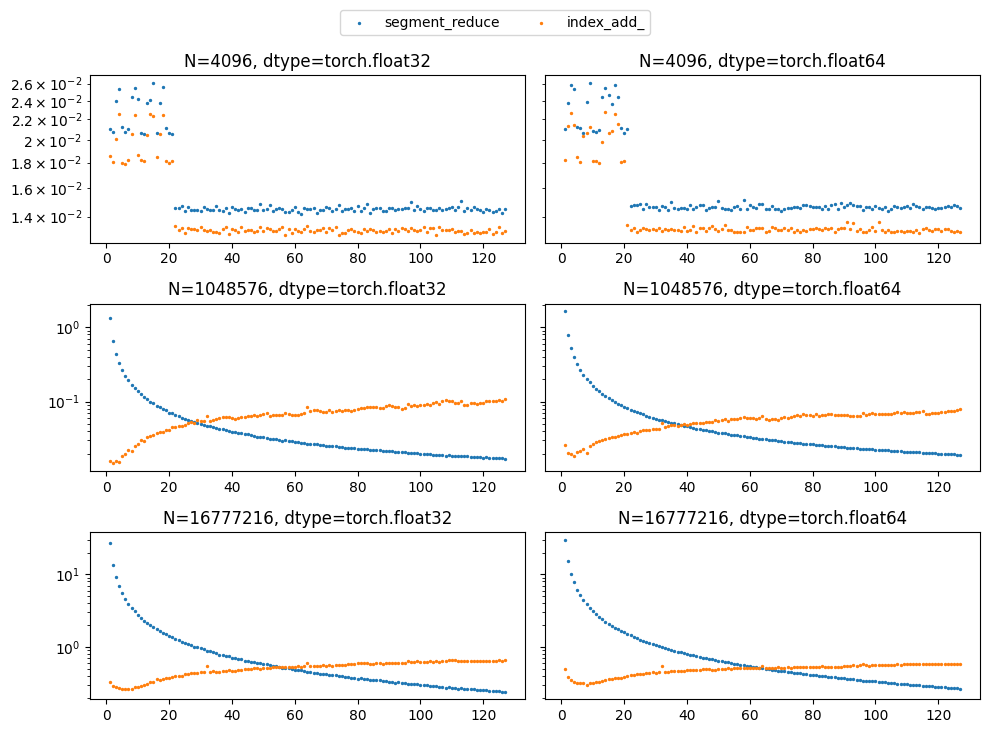

In [156]:
fig, axes = plt.subplots(
    nrows=len(Ns), ncols=len(dtypes), figsize=(10, 7), sharey="row", layout="tight"
)
for i, N in enumerate(Ns):
    for j, dtype in enumerate(dtypes):
        ax = axes[i][j]
        dfd = df[(df.dtype == dtype) & (df.N == N)]
        ax.set_title(f"N={N}, dtype={dtype}")
        for f in funs:
            ax.scatter(
                x=dfd["k"],
                y=dfd[f],
                label=f if i == 0 and j == 0 else None,
                s=2,
            )
        ax.set_yscale("log")
fig.legend(ncols=len(funs), loc="upper center", bbox_to_anchor=(0.5, 1.05))